# 02 — Chunking Strategy

Examine the 3-level hierarchical chunking schema in detail.

**What this notebook covers:**
- Level 1 vs Level 2 chunk comparison
- Context header quality inspection
- `text_to_embed` vs `text` — what the embedder actually sees
- Why the same article at L1 and L2 serves different query types
- Token budget analysis

In [1]:
import json
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('..').resolve()))
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

with open('../data/processed/chunks_dump.json', 'r', encoding='utf-8') as f:
    chunks = json.load(f)
df = pd.DataFrame(chunks)
print(f'Loaded {len(df)} chunks')

Loaded 814 chunks


## 1. The 3-level schema in practice

In [2]:
# Show Art. 9 at both levels side by side
art9_l1 = df[(df['article_num'] == '9') & (df['level'] == 1)]
art9_l2 = df[(df['article_num'] == '9') & (df['level'] == 2)]

print(f'Article 9 appears as:')
print(f'  Level 1: {len(art9_l1)} chunk  ({art9_l1["word_count"].sum()} words — full article)')
print(f'  Level 2: {len(art9_l2)} chunks ({art9_l2["word_count"].sum()} words — individual paragraphs)')
print()
print('L2 paragraph breakdown:')
for _, r in art9_l2.iterrows():
    print(f'  p{r["paragraph_num"]:>2s}: {r["word_count"]:>3} words | {r["text"][:80].strip()}...')

Article 9 appears as:
  Level 1: 1 chunk  (649 words — full article)
  Level 2: 10 chunks (644 words — individual paragraphs)

L2 paragraph breakdown:
  p 1:  18 words | 1.
A risk management system shall be established, implemented, documented and ma...
  p 2: 152 words | 2.
The risk management system shall be understood as a continuous iterative proc...
  p 3:  36 words | 3.
The risks referred to in this Article shall concern only those which may be r...
  p 4:  56 words | 4.
The risk management measures referred to in paragraph 2, point (d), shall giv...
  p 5: 163 words | 5.
The risk management measures referred to in paragraph 2, point (d), shall be...
  p 6:  47 words | 6.
High-risk AI systems shall be tested for the purpose of identifying the most...
  p 7:  14 words | 7.
Testing procedures may include testing in real-world conditions in accordance...
  p 8:  59 words | 8.
The testing of high-risk AI systems shall be performed, as appropriate, at an...
  p 9:  51 words | 9.
When 

In [3]:
# Context header quality — show the full 4-level header for a L2 chunk
sample_l2 = art9_l2.iloc[3]  # paragraph 4
print('=== LEVEL 2 CHUNK — text_to_embed (what mistral-embed receives) ===')
print()
print(sample_l2['text_to_embed'][:600])
print('...')

=== LEVEL 2 CHUNK — text_to_embed (what mistral-embed receives) ===

[Chapter III — HIGH-RISK AI SYSTEMS]
[Section 2 — Requirements for high-risk AI systems]
[Article 9 — Risk management system]
[Article 9, paragraph 4]

4.
The risk management measures referred to in paragraph 2, point (d), shall give due consideration to the effects and 
possible interaction resulting from the combined application of the requirements set out in this Section, with a view to 
minimising risks more effectively while achieving an appropriate balance in implementing the measures to fulfil those 
requirements.
...


In [4]:
# Compare: same content, different granularity
print('WHY TWO LEVELS?')
print('='*65)
print()
print('Query: "What are the general obligations for risk management?"')
print('→ Best served by L1 (full article, broad context)')
print()
print('Query: "Must testing be done before placing AI on the market?"')
print('→ Best served by L2 paragraph 8 specifically')
print()
p8 = art9_l2[art9_l2['paragraph_num'] == '8']
if not p8.empty:
    print('Art. 9(8) text:')
    print(p8.iloc[0]['text'][:300])

WHY TWO LEVELS?

Query: "What are the general obligations for risk management?"
→ Best served by L1 (full article, broad context)

Query: "Must testing be done before placing AI on the market?"
→ Best served by L2 paragraph 8 specifically

Art. 9(8) text:
8.
The testing of high-risk AI systems shall be performed, as appropriate, at any time throughout the development 
process, and, in any event, prior to their being placed on the market or put into service. Testing shall be carried out against 
prior defined metrics and probabilistic thresholds that 


## 2. Context header quality audit

In [5]:
# Sample context headers across different chapters
sample_articles = ['5', '6', '9', '50', '53']

print('Context header quality — sample across key articles:')
print()
for art in sample_articles:
    row = df[(df['article_num'] == art) & (df['level'] == 1)]
    if not row.empty:
        r = row.iloc[0]
        print(f'--- Article {art}: {r["article_name"]} ---')
        print(r['context_header'])
        print()

Context header quality — sample across key articles:

--- Article 5: Prohibited AI practices ---
[Chapter II — PROHIBITED AI PRACTICES]
[Article 5 — Prohibited AI practices]

--- Article 6: Classification rules for high-risk AI systems ---
[Chapter III — HIGH-RISK AI SYSTEMS]
[Section 1 — Classification of AI systems as high-risk]
[Article 6 — Classification rules for high-risk AI systems]

--- Article 9: Risk management system ---
[Chapter III — HIGH-RISK AI SYSTEMS]
[Section 2 — Requirements for high-risk AI systems]
[Article 9 — Risk management system]

--- Article 50: Transparency obligations for providers and deployers of certain AI systems ---
[Chapter IV — TRANSPARENCY OBLIGATIONS FOR PROVIDERS AND DEPLOYERS OF CERTAIN AI SYSTEMS]
[Article 50 — Transparency obligations for providers and deployers of certain AI systems]

--- Article 53: Obligations for providers of general-purpose AI models ---
[Chapter V — GENERAL-PURPOSE AI MODELS]
[Section 2 — Obligations for providers of gene

In [6]:
# Headers with missing context (title/chapter/section null)
missing_chapter = df[df['chapter'].isna() & (df['doc_id'] == 'ai_act')]
print(f'AI Act chunks with missing chapter metadata: {len(missing_chapter)}')
if not missing_chapter.empty:
    print('Examples (first 5):')
    for _, r in missing_chapter.head(5).iterrows():
        print(f'  {r["id"]:40s} | header: {r["context_header"][:60]}')

AI Act chunks with missing chapter metadata: 13
Examples (first 5):
  ai_act_annex_i                           | header: [Annex I]
[List of Union harmonisation legislation]
  ai_act_annex_ii                          | header: [Annex II]
[List of criminal offences referred to in Article
  ai_act_annex_iii                         | header: [Annex III]
[High-risk AI systems referred to in Article 6(2
  ai_act_annex_iv                          | header: [Annex IV]
[Technical documentation referred to in Article 1
  ai_act_annex_v                           | header: [Annex V]
[EU declaration of conformity]


## 3. Token budget analysis

In [7]:
# Estimate tokens for text_to_embed (1 token ≈ 0.75 words for legal English)
df['embed_words'] = df['text_to_embed'].str.split().str.len()
df['embed_tokens_est'] = (df['embed_words'] / 0.75).astype(int)

MISTRAL_EMBED_LIMIT = 8192  # mistral-embed context window
over_limit = df[df['embed_tokens_est'] > MISTRAL_EMBED_LIMIT]

print(f'Token budget analysis (mistral-embed limit: {MISTRAL_EMBED_LIMIT} tokens):')
print(f'  Chunks over limit:  {len(over_limit)} ({len(over_limit)/len(df)*100:.1f}%)')
print(f'  Max tokens:         {df["embed_tokens_est"].max()}')
print(f'  Mean tokens:        {df["embed_tokens_est"].mean():.0f}')
print(f'  Median tokens:      {df["embed_tokens_est"].median():.0f}')

if not over_limit.empty:
    print(f'\nChunks exceeding token limit:')
    for _, r in over_limit.iterrows():
        print(f'  {r["id"]:45s} ~{r["embed_tokens_est"]:,} tokens')

Token budget analysis (mistral-embed limit: 8192 tokens):
  Chunks over limit:  0 (0.0%)
  Max tokens:         6642
  Mean tokens:        266
  Median tokens:      140


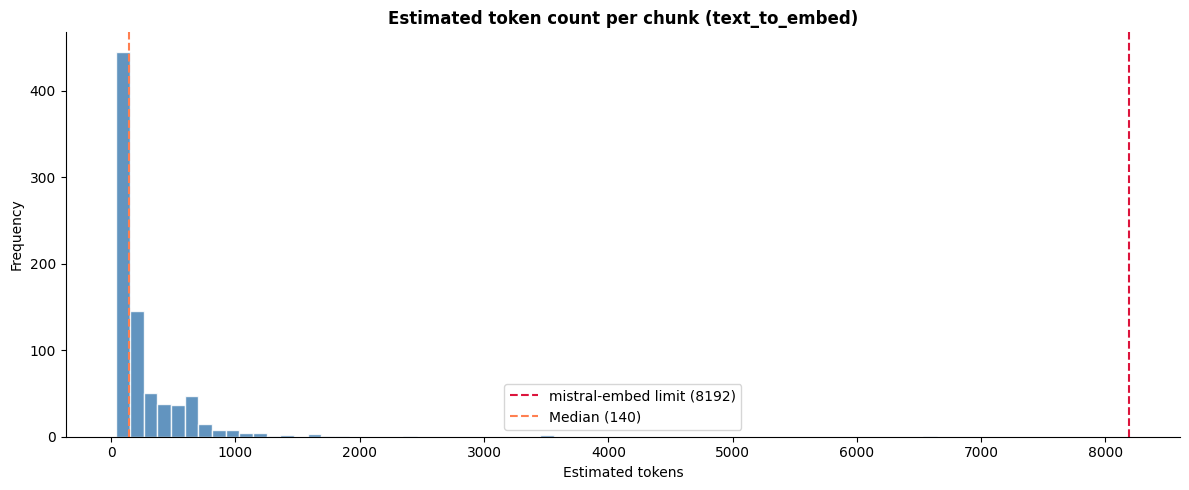

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['embed_tokens_est'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(MISTRAL_EMBED_LIMIT, color='crimson', linestyle='--',
           linewidth=1.5, label=f'mistral-embed limit ({MISTRAL_EMBED_LIMIT})')
ax.axvline(df['embed_tokens_est'].median(), color='coral', linestyle='--',
           linewidth=1.5, label=f'Median ({df["embed_tokens_est"].median():.0f})')
ax.set_title('Estimated token count per chunk (text_to_embed)', fontweight='bold')
ax.set_xlabel('Estimated tokens')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_02_token_budget.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Annex chunking inspection

In [11]:
# Find annex chunks by looking for 'annex' in the id or context header
annexes = df[df['id'].str.contains('annex', case=False, na=False) | 
            df['context_header'].str.contains('ANNEX', case=False, na=False)]
print(f'Annex chunks: {len(annexes)}')
print()
for _, r in annexes.iterrows():
    annex_name = r['id'] if 'annex' in r['id'].lower() else 'Unknown'
    print(f'  {annex_name:20s} | words: {r["word_count"]:4d} | tiers: {r["risk_tiers"]}')
    print(f'  {r["context_header"][:80]}')
    print()

Annex chunks: 33

  Unknown              | words:  605 | tiers: ['high_risk']
  [Chapter III — HIGH-RISK AI SYSTEMS]
[Section 1 — Classification of AI systems a

  Unknown              | words:  102 | tiers: ['high_risk']
  [Chapter III — HIGH-RISK AI SYSTEMS]
[Section 1 — Classification of AI systems a

  Unknown              | words:  409 | tiers: ['high_risk']
  [Chapter III — HIGH-RISK AI SYSTEMS]
[Section 1 — Classification of AI systems a

  Unknown              | words:   88 | tiers: ['high_risk']
  [Chapter III — HIGH-RISK AI SYSTEMS]
[Section 1 — Classification of AI systems a

  Unknown              | words:  375 | tiers: ['all']
  [Chapter VIII — EU DATABASE FOR HIGH-RISK AI SYSTEMS]
[Article 71 — EU database 

  Unknown              | words:  103 | tiers: ['all']
  [Chapter VIII — EU DATABASE FOR HIGH-RISK AI SYSTEMS]
[Article 71 — EU database 

  Unknown              | words:   29 | tiers: ['all']
  [Chapter VIII — EU DATABASE FOR HIGH-RISK AI SYSTEMS]
[Article 71 — EU dat

## 5. GPAI document chunking

In [10]:
gpai = df[df['doc_id'].str.startswith('gpai')]
print(f'GPAI document chunks: {len(gpai)}')
print()
gpai_stats = gpai.groupby('doc_id').agg(
    chunks=('id', 'count'),
    avg_words=('word_count', 'mean'),
    total_words=('word_count', 'sum')
).round(0)
print(gpai_stats.to_string())
print()
print('Sample GPAI chunk (first 400 chars):')
print(gpai.iloc[0]['text'][:400])

GPAI document chunks: 87

                       chunks  avg_words  total_words
doc_id                                               
gpai_cop_copyright          5      416.0         2082
gpai_cop_safety            42      367.0        15403
gpai_cop_transparency       5      338.0         1689
gpai_guidelines            35      442.0        15483

Sample GPAI chunk (first 400 chars):
1 
 
 
Code of Practice for 
General-Purpose AI Models 
 
Transparency Chapter 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
Nuria Oliver 
Rishi Bommasani 
 
Working Group 1 Co-Chair 
Working Group 1 Vice-Chair

2 
Introductory note by the Chair and 
Vice-Chair of the Transparency Chapter. 
The Transparency Chapter of the Code of Practice describes three Measures which Signatories commit 
to impl


## 6. Chunking strategy — key design decisions recap

In [12]:
print('CHUNKING DESIGN DECISIONS')
print('='*65)
print()
print('1. HIERARCHICAL (L1 + L2) rather than sliding window')
print('   → Legal articles are naturally coherent units')
print('   → Paragraphs within articles are distinct obligations')
print('   → Both granularities serve different query types')
print()
print('2. CONTEXT AUGMENTATION HEADERS')
print('   → Every chunk knows its position in the document hierarchy')
print('   → The embedding captures Chapter/Section/Article context')
print('   → Headers are stripped from display (users see clean text)')
print()
print('3. RICH METADATA on every chunk')
print('   → Enables Qdrant payload filtering at query time')
print('   → risk_tier_relevance → pre-filter before semantic search')
print('   → date_application → surface urgency in action plans')
print('   → cross_references → agentic cross-ref resolution')
print()
print('4. SEPARATE GPAI chunking strategy')
print('   → GPAI docs lack Article/Paragraph structure')
print('   → Page-based sliding window for consistent chunk sizes')

# Final stats
print()
print('='*65)
print(f'Result: {len(df)} chunks | avg {df["word_count"].mean():.0f} words | '
      f'{df["embed_tokens_est"].mean():.0f} avg tokens')

CHUNKING DESIGN DECISIONS

1. HIERARCHICAL (L1 + L2) rather than sliding window
   → Legal articles are naturally coherent units
   → Paragraphs within articles are distinct obligations
   → Both granularities serve different query types

2. CONTEXT AUGMENTATION HEADERS
   → Every chunk knows its position in the document hierarchy
   → The embedding captures Chapter/Section/Article context
   → Headers are stripped from display (users see clean text)

3. RICH METADATA on every chunk
   → Enables Qdrant payload filtering at query time
   → risk_tier_relevance → pre-filter before semantic search
   → date_application → surface urgency in action plans
   → cross_references → agentic cross-ref resolution

4. SEPARATE GPAI chunking strategy
   → GPAI docs lack Article/Paragraph structure
   → Page-based sliding window for consistent chunk sizes

Result: 814 chunks | avg 176 words | 266 avg tokens
